
debug_fixedK_linear
closure_mode           = fixedK
prescribed_mode        = linear
use_integrated_mixing  = False
timestep               = 316
max overshoot          = 4.9960 at z = 79.328 cm
max b/U0^2             = 0.1796 at z = 0.053 cm
max K*sigma/U0^2       = 0.0565 at z = 300.000 cm


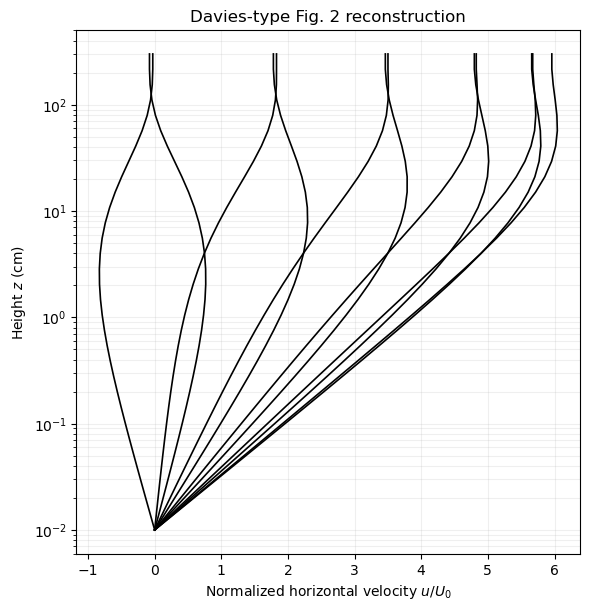

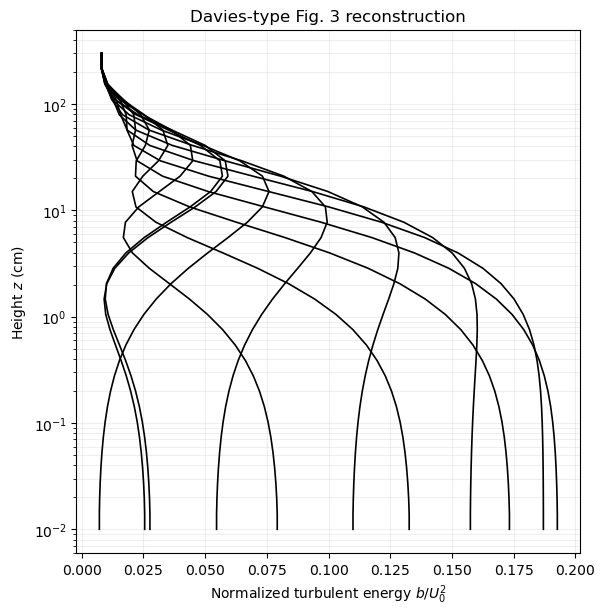

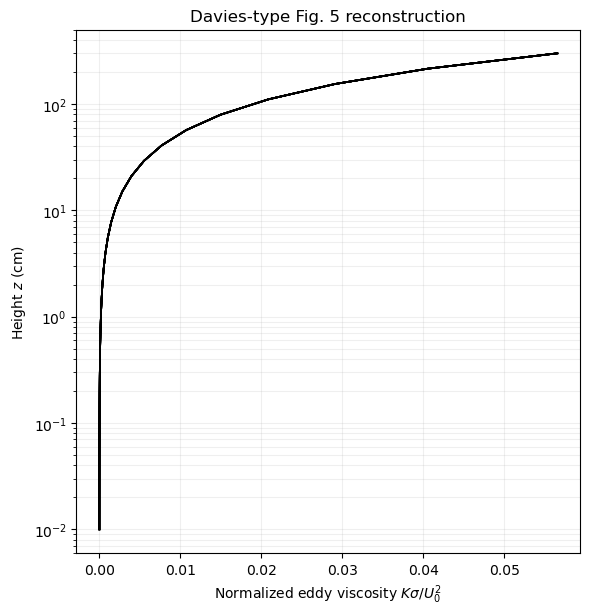

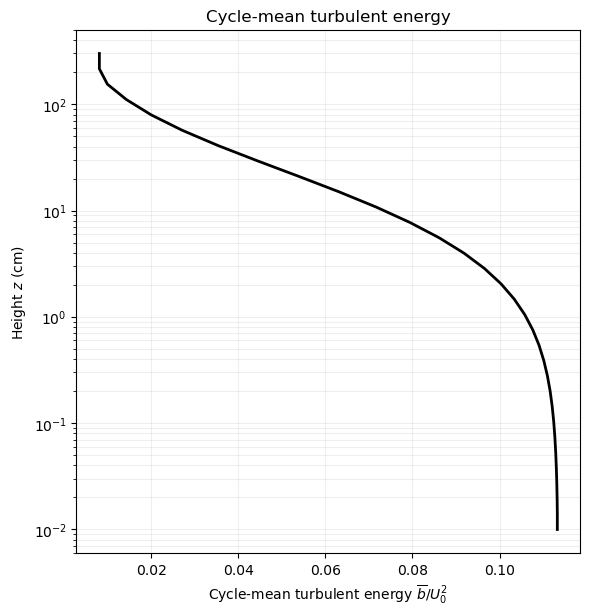

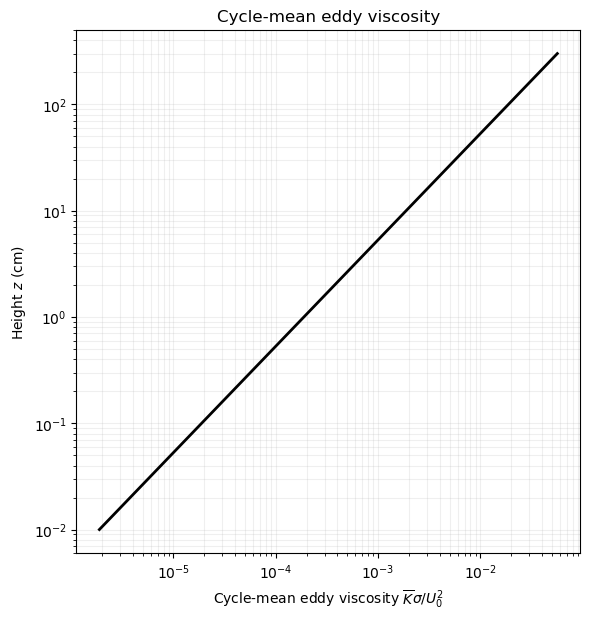

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Davies-type wave bottom boundary layer model
# wave-only version, driven by oscillatory pressure gradient
#
# Units:
#   z : cm
#   u : cm/s
#   t : s
#   K : cm^2/s
#   b : (cm/s)^2
#
# Governing equations:
#
#   du/dt = dUinf/dt + d/dz( K du/dz )
#
#   db/dt = K (du/dz)^2 + (alpha/2) d/dz( K db/dz ) - eps
#
#   K   = c0 * l * sqrt(b)
#   eps = c1 * b^(3/2) / l
#
# Boundary conditions:
#   u = 0                  at z = z0
#   du/dz = 0              at z = ztop
#   K db/dz = 0            at z = z0 and z = ztop
#
# Notes:
#   - top velocity is NOT prescribed; forcing is via dUinf/dt
#   - top-node production is suppressed as a diagnostic
#   - fixedK mode helps isolate the momentum solve
# ============================================================
# This represents about 4 hours of a ChatGPT session, recored here:
# https://chatgpt.com/share/69b4786b-3da0-8007-b212-49ccdb0ac427
#
# which included providing .pdfs of the following papers to the chat:
# Davies, A. G. (1986). A numerical model of the wave boundary layer. Continental Shelf Research, 6(6), 715–739. https://doi.org/10.1016/0278-4343(86)90034-8
# Davies, A. G., Soulsby, R. L., & King, H. L. (1988). A numerical model of the combined wave and current bottom boundary layer. Journal of Geophysical Research: Oceans, 93(C1), 491–508. https://doi.org/10.1029/JC093iC01p00491
#
# Chris Sherwood, csherwood@usgs.gov

# ------------------------------------------------------------
# Tridiagonal solver
# ------------------------------------------------------------
def solve_tridiagonal(a, b, c, d):
    n = len(d)
    ac = a.astype(float).copy()
    bc = b.astype(float).copy()
    cc = c.astype(float).copy()
    dc = d.astype(float).copy()

    for i in range(1, n):
        m = ac[i] / bc[i - 1]
        bc[i] -= m * cc[i - 1]
        dc[i] -= m * dc[i - 1]

    x = np.zeros(n, dtype=float)
    x[-1] = dc[-1] / bc[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (dc[i] - cc[i] * x[i + 1]) / bc[i]
    return x


# ------------------------------------------------------------
# Diffusion operator on nonuniform grid
# ------------------------------------------------------------
def diffusion_matrix(K_face, z):
    """
    Build tridiagonal coefficients for:
        d/dz ( K dphi/dz )
    at cell centers on a nonuniform grid.
    """
    M = len(z)
    lower = np.zeros(M)
    diag = np.zeros(M)
    upper = np.zeros(M)

    for i in range(1, M - 1):
        dzm = z[i] - z[i - 1]
        dzp = z[i + 1] - z[i]
        dzc = 0.5 * (dzm + dzp)

        km = K_face[i - 1]
        kp = K_face[i]

        am = km / (dzm * dzc)
        ap = kp / (dzp * dzc)

        lower[i] = am
        diag[i] = -(am + ap)
        upper[i] = ap

    return lower, diag, upper


def apply_tridiag(lower, diag, upper, x):
    y = diag * x
    y[1:] += lower[1:] * x[:-1]
    y[:-1] += upper[:-1] * x[1:]
    return y


# ------------------------------------------------------------
# Gradients
# ------------------------------------------------------------
def grad_centered(phi, z):
    """
    Centered gradient for diagnostics.
    Top node is set to zero as a diagnostic so the top BC
    does not create artificial production in b.
    """
    g = np.zeros_like(phi)
    g[1:-1] = (phi[2:] - phi[:-2]) / (z[2:] - z[:-2])
    g[0] = (phi[1] - phi[0]) / (z[1] - z[0])
    g[-1] = 0.0
    return g


# ------------------------------------------------------------
# Mixing length
# ------------------------------------------------------------
def mixing_length_linear(z, z0, kappa=0.4):
    return np.maximum(kappa * z, kappa * z0)


def mixing_length_from_b(b, z, z0, kappa=0.4):
    """
    Integrated Davies relation:
        l = kappa * sqrt(b) * [ integral(b^(-1/2) dz) + z0/sqrt(b0) ]
    """
    b_safe = np.maximum(b, 1e-12)
    invsqrt = 1.0 / np.sqrt(b_safe)

    I = np.zeros_like(z)
    for i in range(1, len(z)):
        I[i] = I[i - 1] + 0.5 * (invsqrt[i - 1] + invsqrt[i]) * (z[i] - z[i - 1])

    l = kappa * np.sqrt(b_safe) * (I + z0 / np.sqrt(b_safe[0]))
    l = np.maximum(l, kappa * z0)
    return l


# ------------------------------------------------------------
# Prescribed K profiles for debugging
# ------------------------------------------------------------
def prescribed_K_profile(z, t, sigma, mode="linear", K0=3.0, eps=0.25,
                         zcap=55.0, Kvisc=0.01):
    """
    Prescribed eddy viscosity in cm^2/s.

    mode = "linear"     -> K = K0 * z
    mode = "linear_tv"  -> K = K0 * z * (1 - eps*cos(2*sigma*t))
    mode = "capped"     -> K = K0 * min(z, zcap)
    """
    if mode == "linear":
        K = K0 * z
    elif mode == "linear_tv":
        K = K0 * z * (1.0 - eps * np.cos(2.0 * sigma * t))
    elif mode == "capped":
        K = K0 * np.minimum(z, zcap)
    else:
        raise ValueError("unknown prescribed_K mode")

    return np.maximum(K, Kvisc)


# ------------------------------------------------------------
# Initial K profile for TKE mode
# ------------------------------------------------------------
def initial_K_profile(z, U0, c0, kappa=0.4, Kvisc=0.01):
    """
    Mild initial profile for TKE mode.
    """
    K0 = c0 * (kappa * z) * (0.05 * U0)
    taper = 1.0 / (1.0 + (z / 30.0) ** 2)
    K0 = K0 * taper
    return np.maximum(K0, Kvisc)


# ------------------------------------------------------------
# Crank-Nicolson step for momentum
# ------------------------------------------------------------
def step_u_cn(u_old, K, z, dt, dUdt_half):
    """
    Solve:
        du/dt = dUinf/dt + d/dz( K du/dz )

    BCs:
        u(0)       = 0
        du/dz(top) = 0
    """
    M = len(z)

    K_face = 0.5 * (K[:-1] + K[1:])
    lower, diag, upper = diffusion_matrix(K_face, z)

    rhs = u_old.copy()
    Lu_old = apply_tridiag(lower, diag, upper, u_old)
    rhs[1:-1] += dt * dUdt_half + 0.5 * dt * Lu_old[1:-1]

    a = np.zeros(M)
    b = np.ones(M)
    c = np.zeros(M)
    d = rhs.copy()

    for i in range(1, M - 1):
        a[i] = -0.5 * dt * lower[i]
        b[i] = 1.0 - 0.5 * dt * diag[i]
        c[i] = -0.5 * dt * upper[i]

    # bottom no-slip
    b[0] = 1.0
    d[0] = 0.0

    # top zero shear: u[-1] - u[-2] = 0
    a[-1] = -1.0
    b[-1] = 1.0
    d[-1] = 0.0

    return solve_tridiagonal(a, b, c, d)


# ------------------------------------------------------------
# Crank-Nicolson-like step for turbulent energy
# ------------------------------------------------------------
def step_b_cn(b_old, u_new, K, l, z, dt, alpha, c1):
    """
    Solve:
        db/dt = P + (alpha/2) d/dz( K db/dz ) - eps

    BCs:
        K db/dz = 0 at bottom and top

    Diagnostic choice:
        P[-1] = 0 to avoid top-node production artifact.
    """
    M = len(z)

    dudz = grad_centered(u_new, z)
    P = K * dudz**2
    # supress shear production at the top cell
    # P[-1] = 0.0
    # supress shear production at the top three cells - kind of a kludge?
    P[-3:] = 0.0

    K_face = 0.5 * (K[:-1] + K[1:])
    lower, diag, upper = diffusion_matrix(0.5 * alpha * K_face, z)

    b_safe = np.maximum(b_old, 1e-12)
    eps_coeff = c1 * np.sqrt(b_safe) / np.maximum(l, 1e-12)

    rhs = b_old.copy()
    Lb_old = apply_tridiag(lower, diag, upper, b_old)
    rhs[1:-1] += dt * P[1:-1] + 0.5 * dt * Lb_old[1:-1]

    a = np.zeros(M)
    bb = np.ones(M)
    c = np.zeros(M)
    d = rhs.copy()

    for i in range(1, M - 1):
        a[i] = -0.5 * dt * lower[i]
        bb[i] = 1.0 - 0.5 * dt * diag[i] + dt * eps_coeff[i]
        c[i] = -0.5 * dt * upper[i]

    # bottom zero flux
    bb[0] = 1.0
    c[0] = -1.0
    d[0] = 0.0

    # top zero flux
    a[-1] = -1.0
    bb[-1] = 1.0
    d[-1] = 0.0

    b_new = solve_tridiagonal(a, bb, c, d)
    b_new = np.maximum(b_new, 1e-10)

    return b_new


# ------------------------------------------------------------
# Bed shear stress
# ------------------------------------------------------------
def bed_shear_stress(u, K, z):
    dudz0 = (u[1] - u[0]) / (z[1] - z[0])
    return K[0] * dudz0


# ------------------------------------------------------------
# Main model driver
# ------------------------------------------------------------
def run_davies_model(
    U0=100.0,
    z0=0.01,
    zmax=100.0,
    T=10.0,
    M=26,
    N=60,
    n_cycles=6,
    alpha=0.73,
    c=0.046,
    kappa=0.4,
    n_inner=12,
    closure_mode="fixedK",        # "fixedK" or "tke"
    prescribed_mode="linear",     # "linear", "linear_tv", "capped"
    K0=3.0,
    epsK=0.25,
    zcap=55.0,
    Kvisc=0.01,
    use_integrated_mixing_length=False
):
    """
    Wave-only model driven by:
        Uinf(t) = U0 sin(sigma t)
    so
        dUinf/dt = U0 sigma cos(sigma t)
    """
    sigma = 2.0 * np.pi / T
    dt = T / N

    c0 = c**0.25
    c1 = c**0.75

    z = np.geomspace(z0, zmax, M)
    nt = n_cycles * N
    t_all = np.arange(nt + 1) * dt

    u = np.zeros(M)

    if closure_mode == "fixedK":
        K = prescribed_K_profile(
            z, 0.0, sigma,
            mode=prescribed_mode,
            K0=K0, eps=epsK, zcap=zcap, Kvisc=Kvisc
        )
        l = mixing_length_linear(z, z0, kappa=kappa)
        b = np.maximum((K / (c0 * np.maximum(l, 1e-8)))**2, 1e-8)

    elif closure_mode == "tke":
        K = initial_K_profile(z, U0, c0, kappa=kappa, Kvisc=Kvisc)
        l = mixing_length_linear(z, z0, kappa=kappa)
        b = np.maximum((K / (c0 * np.maximum(l, 1e-8)))**2, 1e-8)

    else:
        raise ValueError("closure_mode must be 'fixedK' or 'tke'")

    u_hist = np.zeros((nt + 1, M))
    b_hist = np.zeros((nt + 1, M))
    l_hist = np.zeros((nt + 1, M))
    K_hist = np.zeros((nt + 1, M))
    Uinf_hist = np.zeros(nt + 1)
    tau0_hist = np.zeros(nt + 1)

    u_hist[0] = u
    b_hist[0] = b
    l_hist[0] = l
    K_hist[0] = K
    Uinf_hist[0] = U0 * np.sin(sigma * t_all[0])
    tau0_hist[0] = bed_shear_stress(u, K, z)

    for n in range(nt):
        t_n = t_all[n]
        t_np1 = t_all[n + 1]
        t_half = 0.5 * (t_n + t_np1)

        Uinf_np1 = U0 * np.sin(sigma * t_np1)
        dUdt_half = U0 * sigma * np.cos(sigma * t_half)

        u_iter = u.copy()
        b_iter = b.copy()

        for _ in range(n_inner):

            if closure_mode == "fixedK":
                K_iter = prescribed_K_profile(
                    z, t_half, sigma,
                    mode=prescribed_mode,
                    K0=K0, eps=epsK, zcap=zcap, Kvisc=Kvisc
                )

                if use_integrated_mixing_length:
                    l_iter = mixing_length_from_b(b_iter, z, z0, kappa=kappa)
                else:
                    l_iter = mixing_length_linear(z, z0, kappa=kappa)

                u_new = step_u_cn(u_iter, K_iter, z, dt, dUdt_half)
                b_new = step_b_cn(b_iter, u_new, K_iter, l_iter, z, dt, alpha, c1)

            else:  # tke
                if use_integrated_mixing_length:
                    l_iter = mixing_length_from_b(b_iter, z, z0, kappa=kappa)
                else:
                    l_iter = mixing_length_linear(z, z0, kappa=kappa)

                K_iter = c0 * l_iter * np.sqrt(np.maximum(b_iter, 1e-12))
                K_iter = np.maximum(K_iter, Kvisc)

                u_new = step_u_cn(u_iter, K_iter, z, dt, dUdt_half)
                b_new = step_b_cn(b_iter, u_new, K_iter, l_iter, z, dt, alpha, c1)

            u_iter = 0.5 * u_iter + 0.5 * u_new
            b_iter = 0.5 * b_iter + 0.5 * b_new

        u = u_iter
        b = np.maximum(b_iter, 1e-10)

        if use_integrated_mixing_length:
            l = mixing_length_from_b(b, z, z0, kappa=kappa)
        else:
            l = mixing_length_linear(z, z0, kappa=kappa)

        if closure_mode == "fixedK":
            K = prescribed_K_profile(
                z, t_np1, sigma,
                mode=prescribed_mode,
                K0=K0, eps=epsK, zcap=zcap, Kvisc=Kvisc
            )
        else:
            K = c0 * l * np.sqrt(np.maximum(b, 1e-12))
            K = np.maximum(K, Kvisc)

        u_hist[n + 1] = u
        b_hist[n + 1] = b
        l_hist[n + 1] = l
        K_hist[n + 1] = K
        Uinf_hist[n + 1] = Uinf_np1
        tau0_hist[n + 1] = bed_shear_stress(u, K, z)

    return {
        "z": z,
        "t": t_all,
        "u_hist": u_hist,
        "b_hist": b_hist,
        "l_hist": l_hist,
        "K_hist": K_hist,
        "Uinf_hist": Uinf_hist,
        "tau0_hist": tau0_hist,
        "params": {
            "U0": U0,
            "z0": z0,
            "zmax": zmax,
            "T": T,
            "M": M,
            "N": N,
            "n_cycles": n_cycles,
            "alpha": alpha,
            "c": c,
            "kappa": kappa,
            "c0": c0,
            "c1": c1,
            "n_inner": n_inner,
            "closure_mode": closure_mode,
            "prescribed_mode": prescribed_mode,
            "K0": K0,
            "epsK": epsK,
            "zcap": zcap,
            "Kvisc": Kvisc,
            "use_integrated_mixing_length": use_integrated_mixing_length
        }
    }


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------
def plot_figure2_velocity(result, fname="davies_fig2_velocity.png"):
    z = result["z"]
    u_hist = result["u_hist"]
    params = result["params"]

    U0 = params["U0"]
    N = params["N"]

    i0 = 5 * N
    i1 = i0 + N // 2
    idx = np.arange(i0, i1 + 1, 3)

    fig, ax = plt.subplots(figsize=(6.5, 6.8))
    for i in idx:
        ax.plot(u_hist[i] / U0, z, color="black", lw=1.2)

    ax.set_yscale("log")
    # ax.set_ylim(z[0], z[-1])
    # ax.set_xlim(-0.1, 1.15)
    ax.set_xlabel(r"Normalized horizontal velocity $u/U_0$")
    ax.set_ylabel(r"Height $z$ (cm)")
    ax.set_title("Davies-type Fig. 2 reconstruction")
    ax.grid(True, which="both", alpha=0.2)

    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


def plot_figure3_energy(result, fname="davies_fig3_energy.png"):
    z = result["z"]
    b_hist = result["b_hist"]
    params = result["params"]

    U0 = params["U0"]
    N = params["N"]

    i0 = 5 * N
    i1 = i0 + N // 2
    idx = np.arange(i0, i1 + 1, 3)

    fig, ax = plt.subplots(figsize=(6.5, 6.8))
    for i in idx:
        ax.plot(b_hist[i] / U0**2, z, color="black", lw=1.2)

    ax.set_yscale("log")
    # ax.set_ylim(z[0], z[-1])
    # ax.set_xlim(0.0, 0.03)
    ax.set_xlabel(r"Normalized turbulent energy $b/U_0^2$")
    ax.set_ylabel(r"Height $z$ (cm)")
    ax.set_title("Davies-type Fig. 3 reconstruction")
    ax.grid(True, which="both", alpha=0.2)

    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


def plot_figure5_viscosity(result, fname="davies_fig5_viscosity.png"):
    z = result["z"]
    K_hist = result["K_hist"]
    params = result["params"]

    U0 = params["U0"]
    T = params["T"]
    N = params["N"]

    sigma = 2.0 * np.pi / T
    i0 = 5 * N
    i1 = i0 + N // 2
    idx = np.arange(i0, i1 + 1, 3)

    fig, ax = plt.subplots(figsize=(6.5, 6.8))
    for i in idx:
        ax.plot(K_hist[i] * sigma / U0**2, z, color="black", lw=1.2)

    ax.set_yscale("log")
    # ax.set_ylim(z[0], z[-1])
    # ax.set_xlim(0.0, 0.08)
    ax.set_xlabel(r"Normalized eddy viscosity $K \sigma / U_0^2$")
    ax.set_ylabel(r"Height $z$ (cm)")
    ax.set_title("Davies-type Fig. 5 reconstruction")
    ax.grid(True, which="both", alpha=0.2)

    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

def plot_mean_energy(result, fname="mean_energy.png"):
    z = result["z"]
    b_hist = result["b_hist"]
    params = result["params"]
    U0 = params["U0"]
    N = params["N"]

    # average over last full cycle
    bmean = b_hist[-N:].mean(axis=0) / U0**2

    fig, ax = plt.subplots(figsize=(6.5, 6.8))
    ax.plot(bmean, z, color="black", lw=2)

    ax.set_yscale("log")
    # ax.set_ylim(z[0], z[-1])
    ax.set_xlabel(r"Cycle-mean turbulent energy $\overline{b}/U_0^2$")
    ax.set_ylabel(r"Height $z$ (cm)")
    ax.set_title("Cycle-mean turbulent energy")
    ax.grid(True, which="both", alpha=0.2)

    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


def plot_mean_viscosity(result, fname="mean_viscosity.png"):
    z = result["z"]
    K_hist = result["K_hist"]
    params = result["params"]
    U0 = params["U0"]
    T = params["T"]
    N = params["N"]

    sigma = 2.0 * np.pi / T
    Kmean = K_hist[-N:].mean(axis=0) * sigma / U0**2

    fig, ax = plt.subplots(figsize=(6.5, 6.8))
    ax.plot(Kmean, z, color="black", lw=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    # ax.set_ylim(z[0], z[-1])
    ax.set_xlabel(r"Cycle-mean eddy viscosity $\overline{K}\sigma/U_0^2$")
    ax.set_ylabel(r"Height $z$ (cm)")
    ax.set_title("Cycle-mean eddy viscosity")
    ax.grid(True, which="both", alpha=0.2)

    fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
def print_diagnostics(result, ts=316):
    z = result["z"]
    u_hist = result["u_hist"]
    b_hist = result["b_hist"]
    K_hist = result["K_hist"]
    params = result["params"]

    U0 = params["U0"]
    T = params["T"]
    sigma = 2.0 * np.pi / T

    u = u_hist[ts] / U0
    b = b_hist[ts] / U0**2
    Kn = K_hist[ts] * sigma / U0**2

    i_over = np.argmax(u - 1.0)
    overshoot = np.max(u - 1.0)

    print(f"closure_mode           = {params['closure_mode']}")
    print(f"prescribed_mode        = {params['prescribed_mode']}")
    print(f"use_integrated_mixing  = {params['use_integrated_mixing_length']}")
    print(f"timestep               = {ts}")
    print(f"max overshoot          = {overshoot:.4f} at z = {z[i_over]:.3f} cm")
    print(f"max b/U0^2             = {np.max(b):.4f} at z = {z[np.argmax(b)]:.3f} cm")
    print(f"max K*sigma/U0^2       = {np.max(Kn):.4f} at z = {z[np.argmax(Kn)]:.3f} cm")


def run_and_plot(label, **kwargs):
    result = run_davies_model(**kwargs)

    print("\n" + "=" * 72)
    print(label)
    print("=" * 72)
    print_diagnostics(result, ts=316)

    plot_figure2_velocity(result, fname=f"{label}_fig2_velocity.png")
    plot_figure3_energy(result, fname=f"{label}_fig3_energy.png")
    plot_figure5_viscosity(result, fname=f"{label}_fig5_viscosity.png")
    plot_mean_energy(result, fname=f"{label}_mean_energy.png")
    plot_mean_viscosity(result, fname=f"{label}_mean_viscosity.png")

    return result


# ------------------------------------------------------------
# Example main block
# ------------------------------------------------------------
if __name__ == "__main__":
    result = run_and_plot(
        "debug_fixedK_linear",
        U0=100.0,
        z0=0.01,
        zmax=300.0,
        T=10.0,
        M=32,
        N=60,
        n_cycles=6,
        alpha=0.73,
        c=0.046,
        kappa=0.4,
        n_inner=12,
        closure_mode="fixedK",
        prescribed_mode="linear",
        K0=3.0,
        epsK=0.0,
        zcap=55.0,
        Kvisc=0.01,
        use_integrated_mixing_length=False
    )


debug_fixedK_linear_tv
closure_mode           = fixedK
prescribed_mode        = linear_tv
use_integrated_mixing  = False
timestep               = 316
max overshoot          = 5.0854 at z = 100.000 cm
max b/U0^2             = 0.2042 at z = 0.044 cm
max K*sigma/U0^2       = 0.0235 at z = 100.000 cm


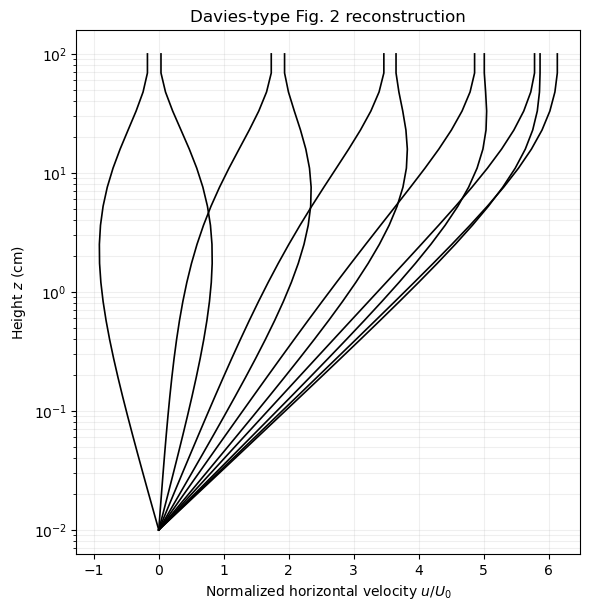

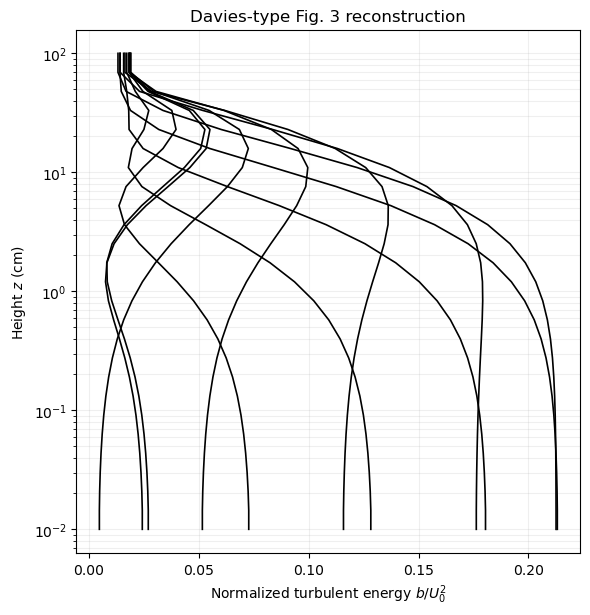

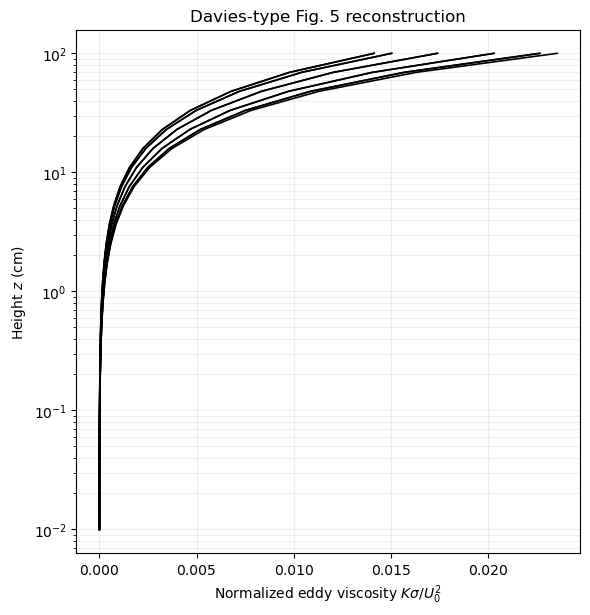

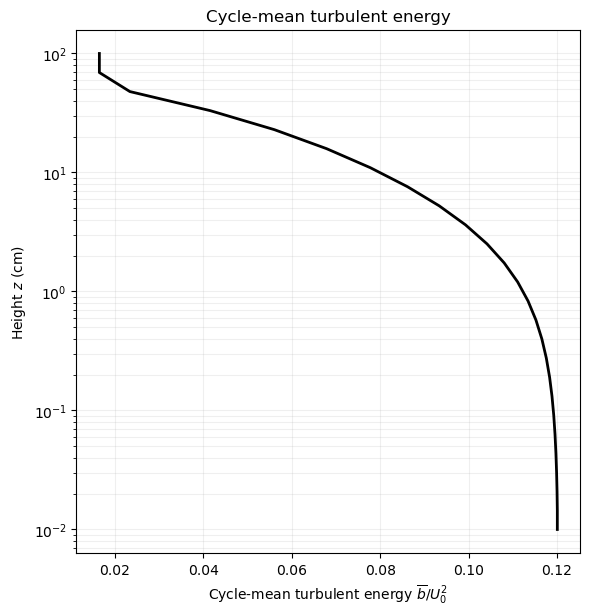

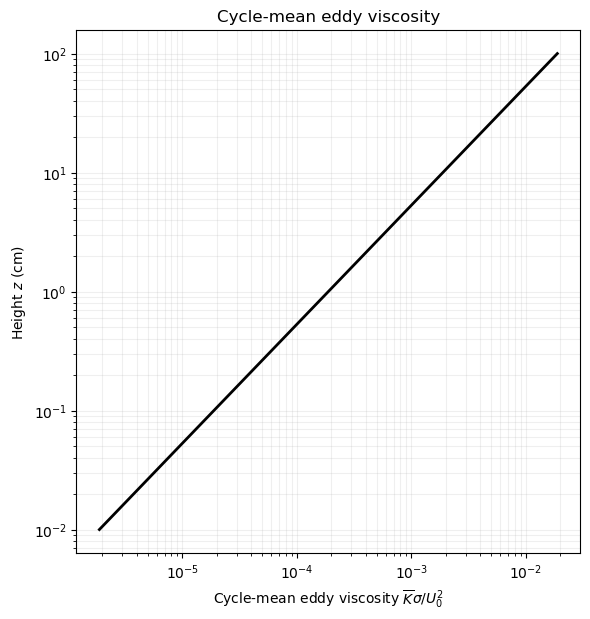

In [2]:
result2 = run_and_plot(
    "debug_fixedK_linear_tv",
    U0=100.0,
    z0=0.01,
    zmax=100.0,
    T=10.0,
    M=26,
    N=60,
    n_cycles=6,
    alpha=0.73,
    c=0.046,
    kappa=0.4,
    n_inner=12,
    closure_mode="fixedK",
    prescribed_mode="linear_tv",
    K0=3.0,
    epsK=0.25,
    zcap=55.0,
    Kvisc=0.01,
    use_integrated_mixing_length=False
)


debug_tke_integrated_mixing_zmax200
closure_mode           = tke
prescribed_mode        = linear
use_integrated_mixing  = True
timestep               = 316
max overshoot          = 6.1921 at z = 154.268 cm
max b/U0^2             = 0.4171 at z = 0.199 cm
max K*sigma/U0^2       = 0.0521 at z = 300.000 cm


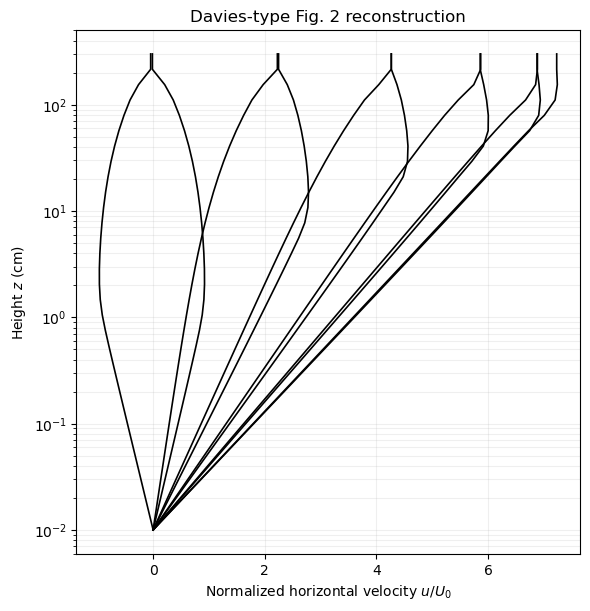

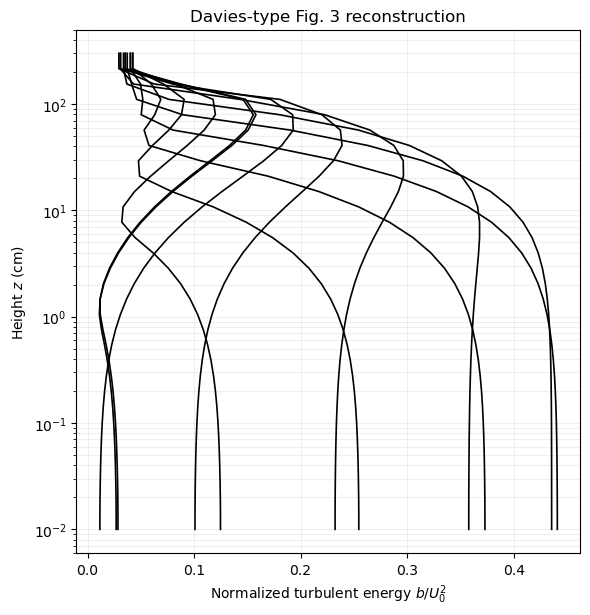

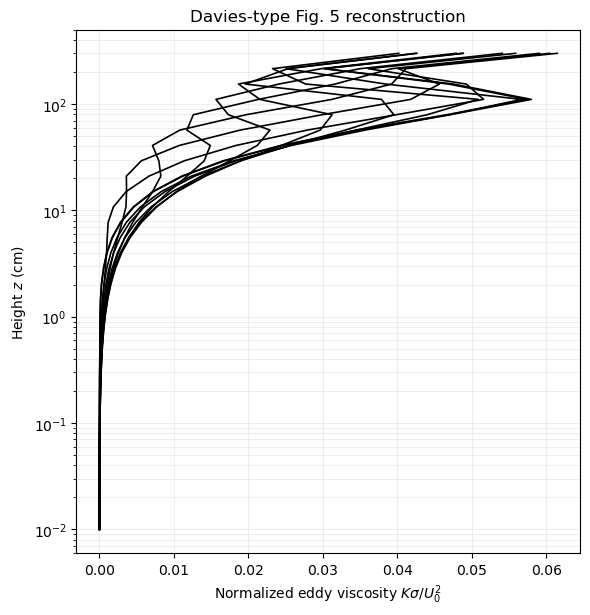

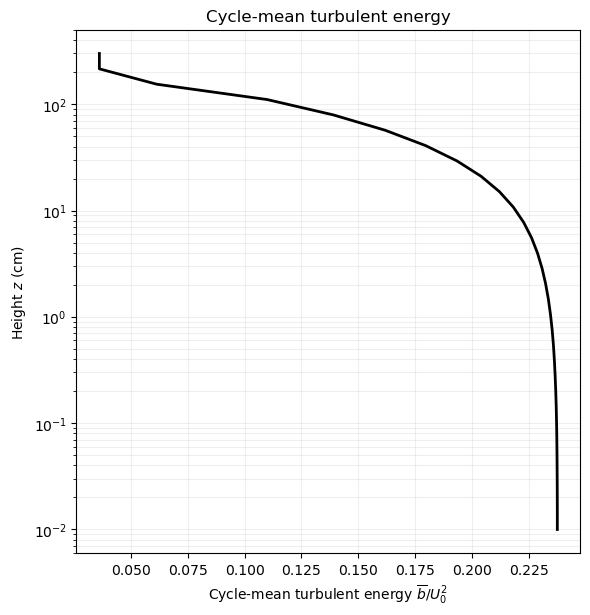

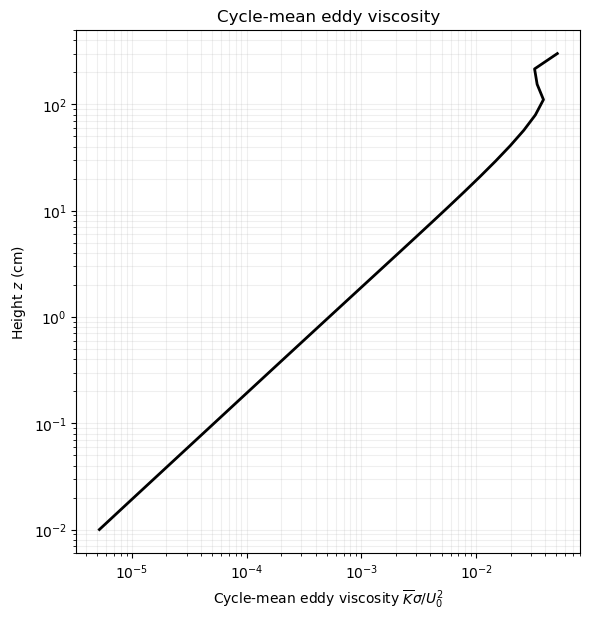

In [3]:
result6 = run_and_plot(
    "debug_tke_integrated_mixing_zmax200",
    U0=100.0,
    z0=0.01,
    zmax=300.0,
    T=10.0,
    M=32,
    N=60,
    n_cycles=6,
    alpha=0.73,
    c=0.046,
    kappa=0.4,
    n_inner=14,
    closure_mode="tke",
    prescribed_mode="linear",
    K0=3.0,
    epsK=0.25,
    zcap=55.0,
    Kvisc=0.01,
    use_integrated_mixing_length=True
)


debug_fixedK_capped
closure_mode           = fixedK
prescribed_mode        = capped
use_integrated_mixing  = False
timestep               = 316
max overshoot          = 5.0865 at z = 69.183 cm
max b/U0^2             = 0.1787 at z = 0.063 cm
max K*sigma/U0^2       = 0.0104 at z = 69.183 cm


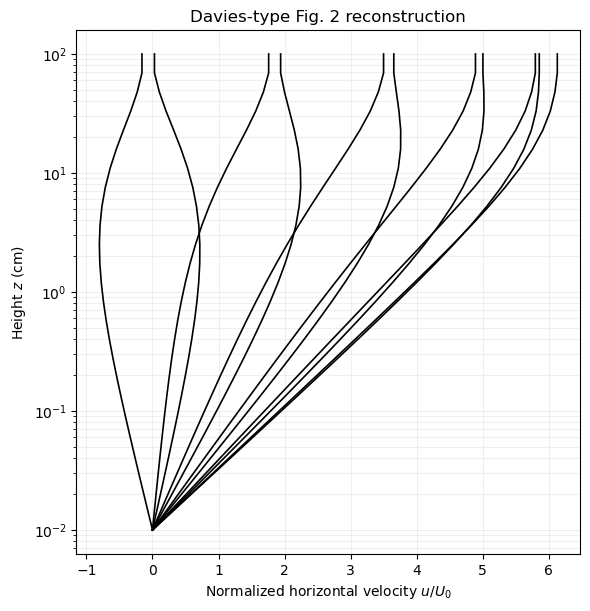

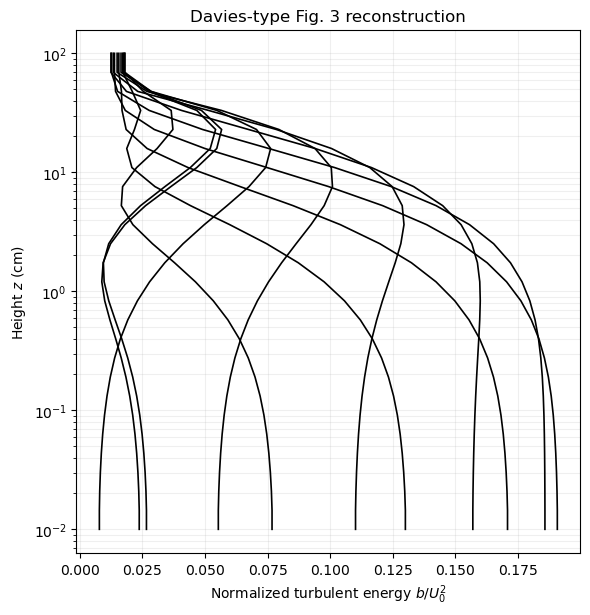

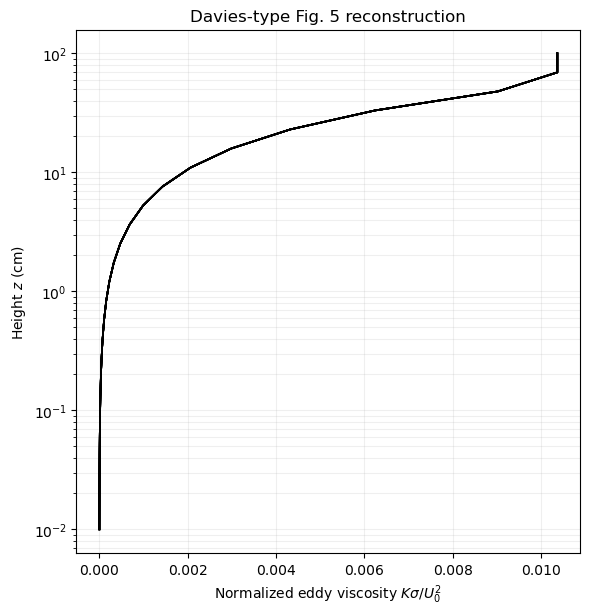

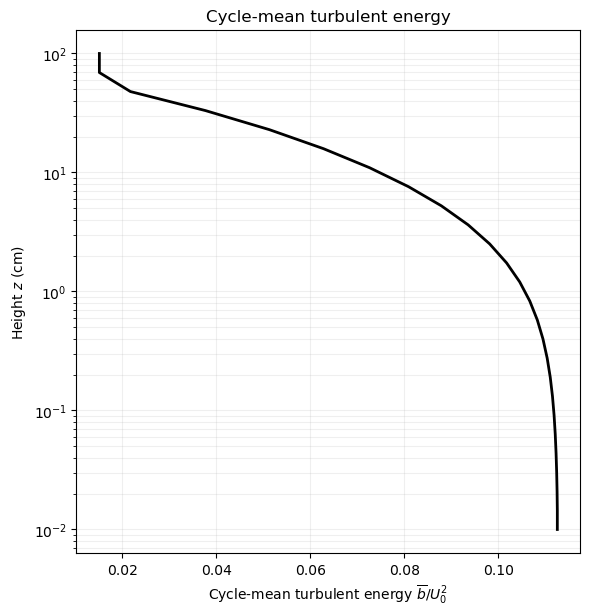

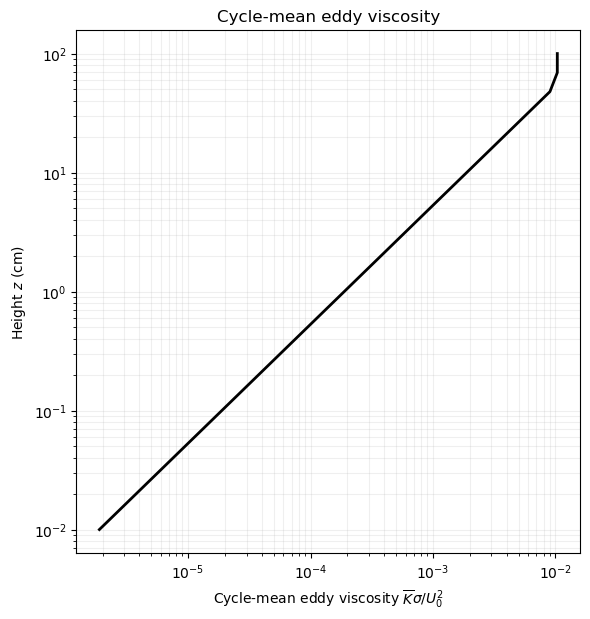

In [4]:
result3 = run_and_plot(
    "debug_fixedK_capped",
    U0=100.0,
    z0=0.01,
    zmax=100.0,
    T=10.0,
    M=26,
    N=60,
    n_cycles=6,
    alpha=0.73,
    c=0.046,
    kappa=0.4,
    n_inner=12,
    closure_mode="fixedK",
    prescribed_mode="capped",
    K0=3.0,
    epsK=0.0,
    zcap=55.0,
    Kvisc=0.01,
    use_integrated_mixing_length=False
)


debug_tke_linear_mixing
closure_mode           = tke
prescribed_mode        = linear
use_integrated_mixing  = False
timestep               = 316
max overshoot          = 5.9980 at z = 69.183 cm
max b/U0^2             = 0.4772 at z = 0.091 cm
max K*sigma/U0^2       = 0.0366 at z = 100.000 cm


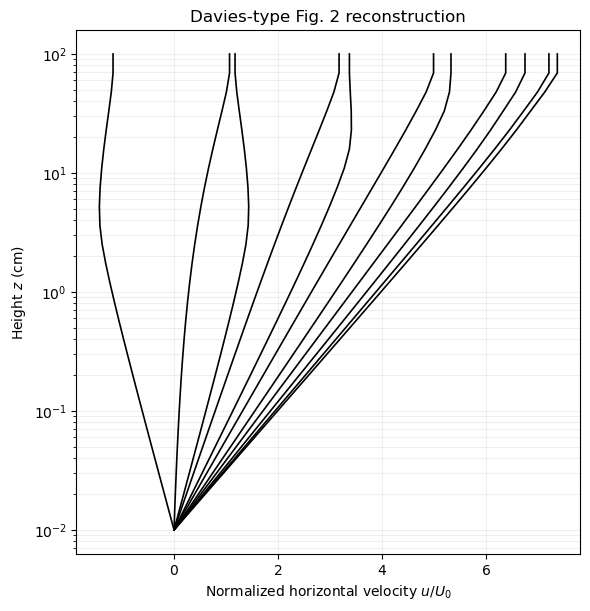

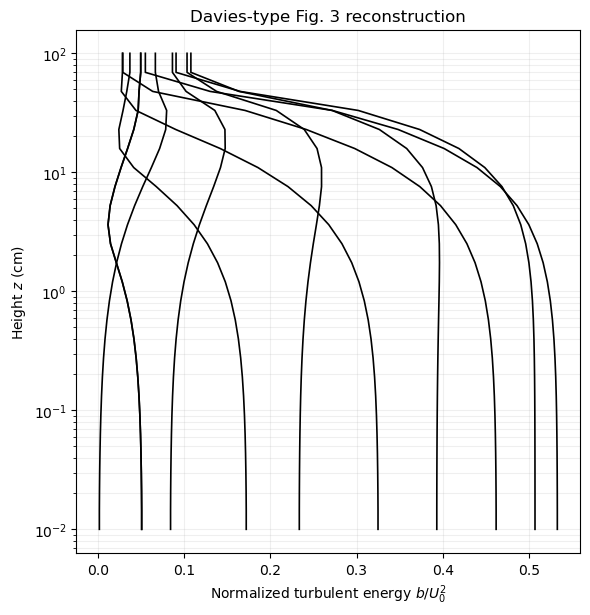

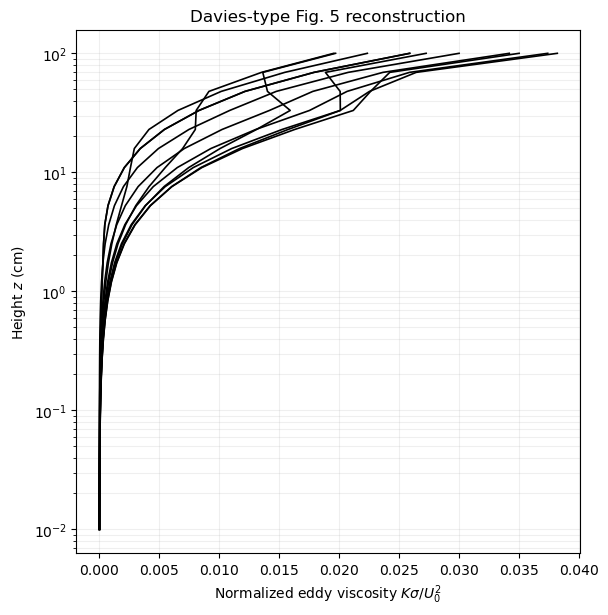

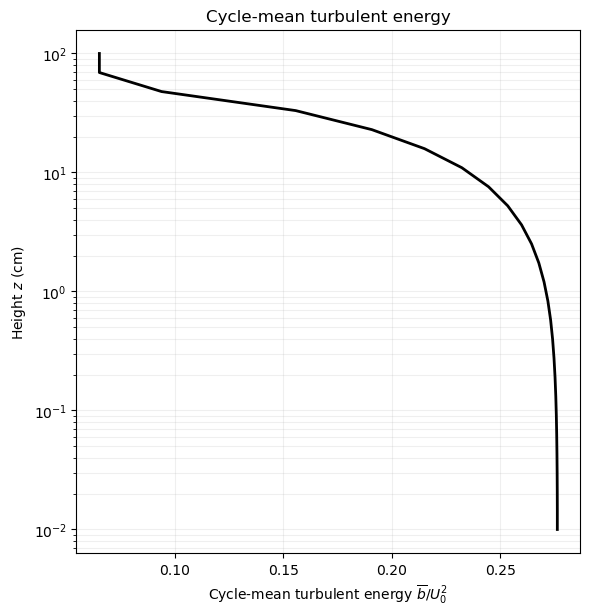

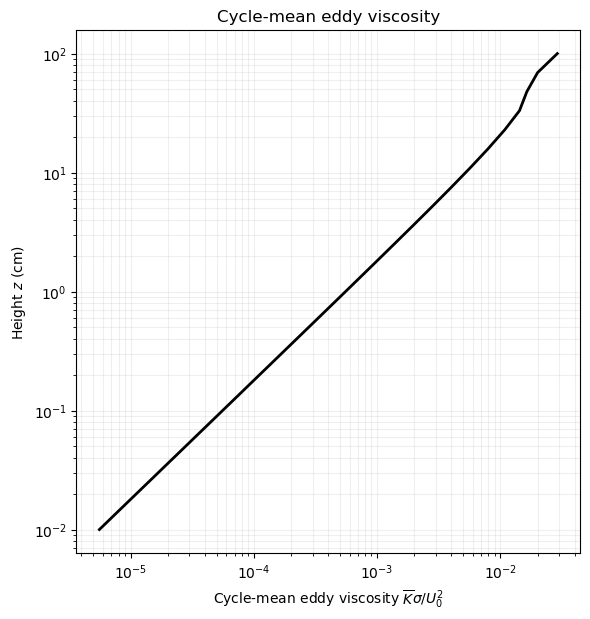

In [5]:
result4 = run_and_plot(
    "debug_tke_linear_mixing",
    U0=100.0,
    z0=0.01,
    zmax=100.0,
    T=10.0,
    M=26,
    N=60,
    n_cycles=6,
    alpha=0.73,
    c=0.046,
    kappa=0.4,
    n_inner=14,
    closure_mode="tke",
    prescribed_mode="linear",
    K0=3.0,
    epsK=0.25,
    zcap=55.0,
    Kvisc=0.01,
    use_integrated_mixing_length=False
)


debug_tke_integrated_mixing
closure_mode           = tke
prescribed_mode        = linear
use_integrated_mixing  = True
timestep               = 316
max overshoot          = 6.2608 at z = 69.183 cm
max b/U0^2             = 0.4590 at z = 0.132 cm
max K*sigma/U0^2       = 0.0192 at z = 33.113 cm


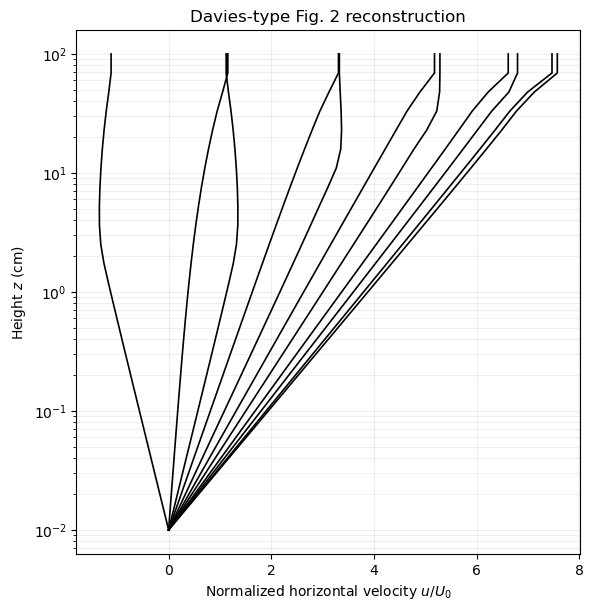

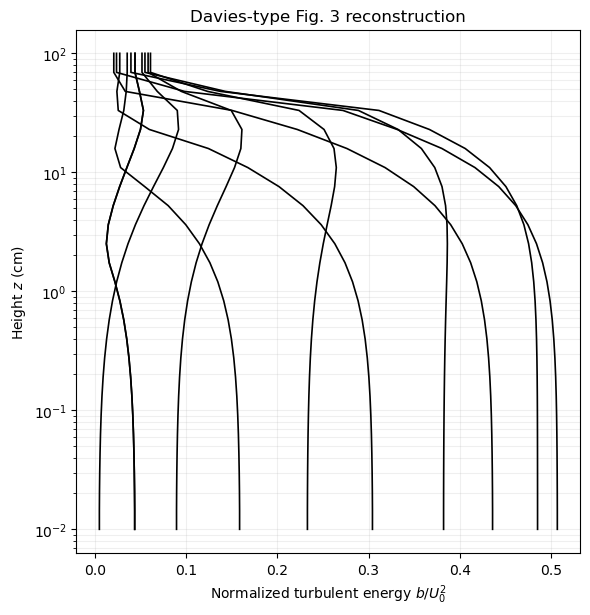

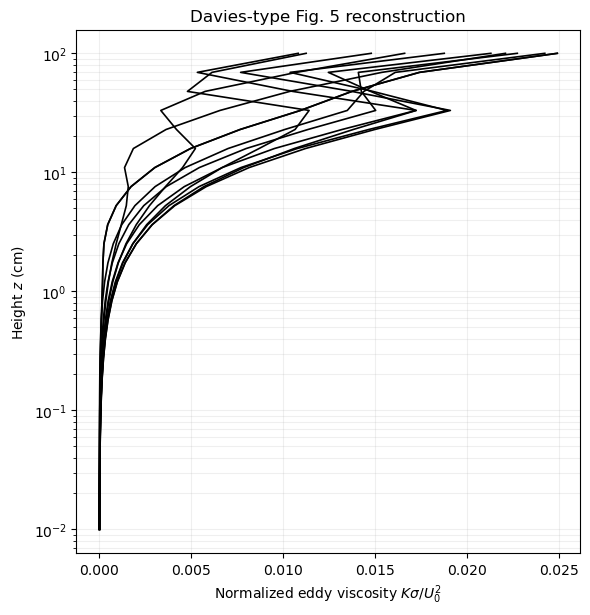

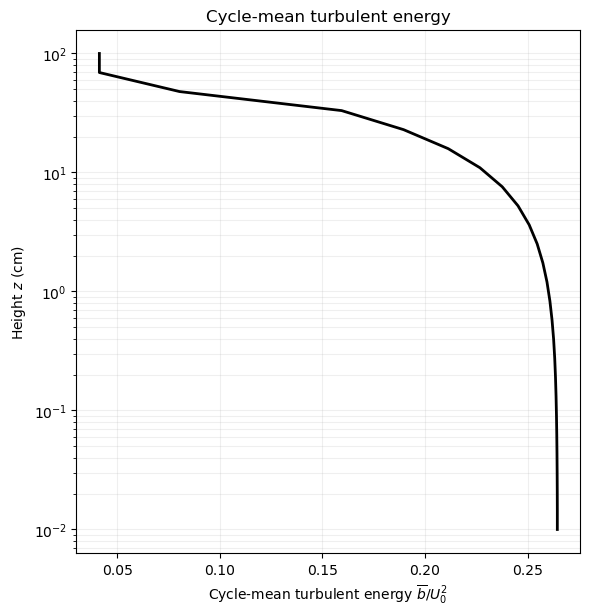

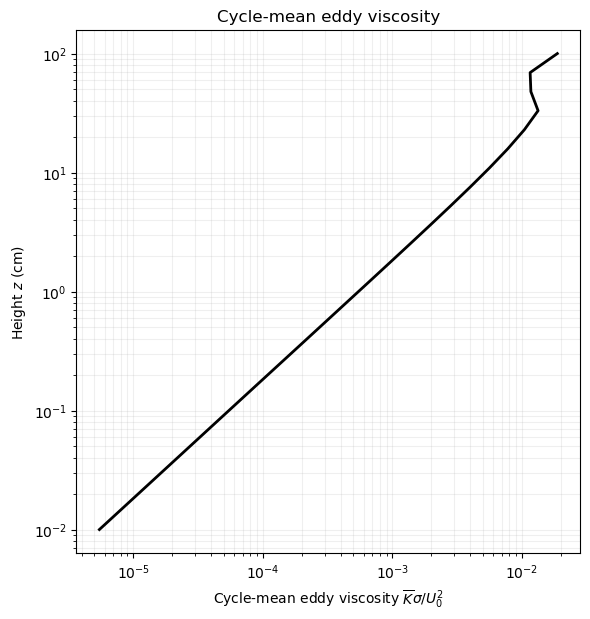

In [6]:
result5 = run_and_plot(
    "debug_tke_integrated_mixing",
    U0=100.0,
    z0=0.01,
    zmax=100.0,
    T=10.0,
    M=26,
    N=60,
    n_cycles=6,
    alpha=0.73,
    c=0.046,
    kappa=0.4,
    n_inner=14,
    closure_mode="tke",
    prescribed_mode="linear",
    K0=3.0,
    epsK=0.25,
    zcap=55.0,
    Kvisc=0.01,
    use_integrated_mixing_length=True
)